# Imports

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import os
import h5py
import static_utils
import pathlib
import pandas as pd
import seaborn as sns
from scipy import stats

%matplotlib inline

In [2]:
%pwd

'/home/lbiswas/Code/gh-prep/mr-tracking-tests-arjun/Static_Tracking'

# Constants and Paths

In [3]:
# Main data paths for each catheter (manually input)
prepend = '/data' # Change to empty string after zenodo get
parent_path = prepend + '/processed'
if (not os.path.isdir(parent_path)):
    print("Using precomputed outputs")
    parent_path = '../data/preprocessed'

class YLoc:
    def __init__(self, description=None, input_path_suffix=None, export_path_suffix=None):
        self.description = description
        self.in_suffix = input_path_suffix
        self.out_suffix = export_path_suffix
        
y_locations = [YLoc('Y = 45mm','Y0','Y45mm'), YLoc('Y = 20mm','Y1', 'Y20mm'), YLoc('Y = -5mm', 'Y2', 'Y-5mm')]
catheter_labels = ['C222','C231','C306']

main_paths = {} # input coordinate data from each catheter and position
heatmap_paths = {} # exported heatmap plots
xpmt_date_dict = {
    (catheter_labels[0],'Y0'):'17Aug2021',
    (catheter_labels[1],'Y0'):'15Dec2021',
    (catheter_labels[2],'Y0'):'13Dec2021',
    (catheter_labels[0],'Y1'):'8Nov2021',
    (catheter_labels[1],'Y1'):'21Dec2021',
    (catheter_labels[2],'Y1'):'6Jan2022',
    (catheter_labels[0],'Y2'):'9Nov2021',
    (catheter_labels[1],'Y2'):'9Jan2022',
    (catheter_labels[2],'Y2'):'7Jan2022',
}
for yloc in y_locations:
    main_paths[yloc.in_suffix] = []
    for cath in catheter_labels:
        xpmt_date = xpmt_date_dict[(cath,yloc.in_suffix)]
        main_paths[yloc.in_suffix].append(f'{parent_path}/static/trackTest-{xpmt_date}-{cath}-{yloc.in_suffix}/')
    heatmap_paths[yloc.in_suffix] = f'../reports/figures/static/{yloc.out_suffix}/'
        
#main_path_222 = parent_path + '/static/trackTest-17Aug2021-C222-Y0/'
#main_path_231 = parent_path + '/static/trackTest-15Dec2021-C231-Y0/'
#main_path_306 = parent_path + '/static/trackTest-13Dec2021-C306-Y0/'

#main_path = [main_path_222, main_path_231, main_path_306]

# Where you would like to save the heatmaps (manually input)
#heatmap_path = '../reports/figures/static/Y45mm/'

# Tip error data is also exported to HDF5 files
error_path = '../reports/export/static/'

Gt_filename = '1GroundTruthCoords.csv'

geometry_index = 1

max_samples = 170

Using precomputed outputs


In [4]:
def get_catheter_from_path(path):
    for c in catheter_labels:
        if c in path:
            return c
    return None

Ensure sample numbers match across positions: recordings were 15 seconds in 3P, but 5 seconds in HM so "crop" the list of biases in 3P. Also remove the NaNs at the end of the bias lists that are the result of multi-threaded coil recordings ending at slightly different times.

In [5]:
def check_nans(biases):
    """ Check if the only NaNs are clustered in the tail, with no non-NaNs after the first NaN
    """
    bias_nans = np.isnan(biases)
    if bias_nans.sum() == 0: # No NaNs
        return True
    first_nan_ind = np.argmax(bias_nans)
    return np.all(bias_nans[first_nan_ind:])

def crop_tails(biases):
    """ Crop everything after the first NaN
    """
    bias_nans = np.isnan(biases)
    if bias_nans.sum() == 0: # No NaNs
        return biases # don't crop
    first_nan_ind = np.argmax(bias_nans)
    print(f'first NaN at {first_nan_ind} out of {len(biases)} elements')
    return biases[0:first_nan_ind]
                              
def crop_bias_list(bias_list, yloc, gridloc, catheter, shorter_sequence, df):
    # find the first combination of location and catheter from a different (shorter) sequence in the dataframe
    # and return the given bias list, shortened so that it matches the number of samples from the other sequence
    other_row = df[(df['Sequence']==shorter_sequence) & (df['Y_Loc']==yloc) & (df['Grid_Loc']==gridloc) & \
                   (df['Catheter']==catheter)]
    if len(other_row) < 1:
        print('**ERR** Target not found. Not cropping.')
        return bias_list
    target = other_row.iloc[0]['Biases_Crop']
    if (len(target) >= len(bias_list)):
        print(f'**WARN** Target of size {len(target)} not shorter than bias list of size {len(bias_list)}. Not cropping.')
        return bias_list
    print(f'*INFO* y-loc {yloc}, grid-loc {gridloc}, cath{catheter} - cropping from {len(bias_list)} to {len(target)}')
    return bias_list[0:len(target)]

# Error Heatmaps

For each sequence and localization algorithm of interest, plot the heatmap of average tip errors at each position. Each position has recordings from three catheters.

In [6]:
sequences = ['SRI_Original', 'FH512_noDither_gradSpoiled']
algorithms = ['centroid_around_peak', 'jpng']
aggregate_data = []
aggregate_plot = []

os.makedirs(error_path, exist_ok=True)

for yloc in y_locations:
    for seq in sequences:
        for alg in algorithms:
            main_path = main_paths[yloc.in_suffix]
            path_dct = static_utils.get_catheter_data(main_path, seq, alg, Gt_filename, geometry_index, max_samples)
            # Aggregate
            for path in main_path: # path per catheter
                cath_label = get_catheter_from_path(path)
                coord_stats = path_dct[path][0]
                coord_biases = path_dct[path][1]
                for loc in range(16): # for each grid location
                    bias = coord_stats[loc][2]
                    variance =  coord_stats[loc][3]
                    count = coord_stats[loc][4]
                    gt_x = coord_stats[loc][0]
                    gt_z = coord_stats[loc][1]
                    aggregate_data.append({'Y_Loc': yloc.in_suffix, 'Sequence':seq, 'Algorithm': alg, \
                                           'Catheter':cath_label, 'Grid_Loc':loc+1, 'Mean_Bias':bias, \
                                           'Biases':coord_biases[loc], 'Variance':variance, 'Count':count, \
                                          'GT_X':gt_x, 'GT_Z':gt_z})
            aggregate_plot.append({'Y_Loc': yloc, 'Sequence':seq, 'Algorithm': alg, 'Path_Dict':path_dct})

In [7]:
# TO DO: Recording lengths do not match: crop to the first 5 seconds
agg_df = pd.DataFrame(aggregate_data)
agg_df['Biases_Crop'] = agg_df['Biases']
nan_tails = agg_df.apply(lambda x: check_nans(x['Biases']), axis=1)
np.all(nan_tails)

True

In [8]:
agg_df[agg_df['Count']==0] # Missed recording from a sequence at one grid location

,Y_Loc,Sequence,Algorithm,Catheter,Grid_Loc,Mean_Bias,Biases,Variance,Count,GT_X,GT_Z,Biases_Crop
417,Y2,SRI_Original,centroid_around_peak,C306,2,0.0,[],0.0,0.0,29.693695,-18.650055,[]
465,Y2,SRI_Original,jpng,C306,2,0.0,[],0.0,0.0,29.693695,-18.650055,[]


In [9]:
agg_df = agg_df.drop(agg_df[agg_df['Count']==0].index)

In [10]:
agg_df['Biases_Crop'] = agg_df.apply(lambda x: crop_tails(x['Biases']),axis=1)

In [11]:
agg_df['Biases_Crop'] = agg_df.apply(lambda x: x['Biases_Crop'] if x['Sequence'] != 'SRI_Original' else \
                                       crop_bias_list(x['Biases_Crop'], x['Y_Loc'], x['Grid_Loc'], \
                                                      x['Catheter'],'FH512_noDither_gradSpoiled', agg_df), \
                                       axis=1)

*INFO* y-loc Y0, grid-loc 1, cathC222 - cropping from 337 to 181
*INFO* y-loc Y0, grid-loc 1, cathC222 - cropping from 337 to 181
*INFO* y-loc Y0, grid-loc 2, cathC222 - cropping from 339 to 182
*INFO* y-loc Y0, grid-loc 3, cathC222 - cropping from 346 to 181
*INFO* y-loc Y0, grid-loc 4, cathC222 - cropping from 340 to 183
*INFO* y-loc Y0, grid-loc 5, cathC222 - cropping from 356 to 177
*INFO* y-loc Y0, grid-loc 6, cathC222 - cropping from 334 to 174
*INFO* y-loc Y0, grid-loc 7, cathC222 - cropping from 333 to 178
*INFO* y-loc Y0, grid-loc 8, cathC222 - cropping from 345 to 174
*INFO* y-loc Y0, grid-loc 9, cathC222 - cropping from 353 to 172
*INFO* y-loc Y0, grid-loc 10, cathC222 - cropping from 356 to 181
*INFO* y-loc Y0, grid-loc 11, cathC222 - cropping from 348 to 173
*INFO* y-loc Y0, grid-loc 12, cathC222 - cropping from 357 to 179
*INFO* y-loc Y0, grid-loc 13, cathC222 - cropping from 355 to 181
*INFO* y-loc Y0, grid-loc 14, cathC222 - cropping from 336 to 182
*INFO* y-loc Y0, gri

*INFO* y-loc Y1, grid-loc 7, cathC231 - cropping from 354 to 181
*INFO* y-loc Y1, grid-loc 8, cathC231 - cropping from 355 to 179
*INFO* y-loc Y1, grid-loc 9, cathC231 - cropping from 344 to 183
*INFO* y-loc Y1, grid-loc 10, cathC231 - cropping from 338 to 180
*INFO* y-loc Y1, grid-loc 11, cathC231 - cropping from 336 to 178
*INFO* y-loc Y1, grid-loc 12, cathC231 - cropping from 346 to 183
*INFO* y-loc Y1, grid-loc 13, cathC231 - cropping from 338 to 174
*INFO* y-loc Y1, grid-loc 14, cathC231 - cropping from 336 to 180
*INFO* y-loc Y1, grid-loc 15, cathC231 - cropping from 346 to 180
*INFO* y-loc Y1, grid-loc 16, cathC231 - cropping from 335 to 181
*INFO* y-loc Y1, grid-loc 1, cathC306 - cropping from 351 to 175
*INFO* y-loc Y1, grid-loc 2, cathC306 - cropping from 336 to 184
*INFO* y-loc Y1, grid-loc 3, cathC306 - cropping from 342 to 176
*INFO* y-loc Y1, grid-loc 4, cathC306 - cropping from 346 to 179
*INFO* y-loc Y1, grid-loc 5, cathC306 - cropping from 346 to 178
*INFO* y-loc Y1, g

In [12]:
agg_df

,Y_Loc,Sequence,Algorithm,Catheter,Grid_Loc,Mean_Bias,Biases,Variance,Count,GT_X,GT_Z,Biases_Crop
0,Y0,SRI_Original,centroid_around_peak,C222,1,1.970112,"[1.9833520602399075, 2.0714497764852036, 1.812...",0.003940,337.0,-2.609326,-21.936268,"[1.9833520602399075, 2.0714497764852036, 1.812..."
1,Y0,SRI_Original,centroid_around_peak,C222,2,3.175268,"[3.090043110615727, 3.126779341178156, 3.09207...",0.003491,339.0,30.943948,-22.098604,"[3.090043110615727, 3.126779341178156, 3.09207..."
2,Y0,SRI_Original,centroid_around_peak,C222,3,0.948233,"[1.1408342182641895, 0.9749383302433562, 1.095...",0.096054,346.0,64.474602,-22.240331,"[1.1408342182641895, 0.9749383302433562, 1.095..."
3,Y0,SRI_Original,centroid_around_peak,C222,4,2.855528,"[2.925006311464213, 2.7307822863905487, 2.9305...",0.002422,340.0,97.597368,-21.155930,"[2.925006311464213, 2.7307822863905487, 2.9305..."
4,Y0,SRI_Original,centroid_around_peak,C222,5,2.708824,"[2.7734128719347777, 2.6661149919671536, 2.653...",0.003078,356.0,98.385867,11.853434,"[2.7734128719347777, 2.6661149919671536, 2.653..."
...,...,...,...,...,...,...,...,...,...,...,...,...
571,Y2,FH512_noDither_gradSpoiled,jpng,C306,12,1.977405,"[2.0967337921131093, 2.098694082491882, 2.1577...",0.003875,177.0,96.287750,49.580823,"[2.0967337921131093, 2.098694082491882, 2.1577..."
572,Y2,FH512_noDither_gradSpoiled,jpng,C306,13,1.635901,"[1.7734196051076967, 1.7106319403999157, 1.726...",0.005339,182.0,96.215453,82.892297,"[1.7734196051076967, 1.7106319403999157, 1.726..."
573,Y2,FH512_noDither_gradSpoiled,jpng,C306,14,1.933651,"[2.0415259202574005, 2.3109337099813385, 2.288...",0.010329,179.0,62.903314,82.553024,"[2.0415259202574005, 2.3109337099813385, 2.288..."
574,Y2,FH512_noDither_gradSpoiled,jpng,C306,15,1.887507,"[2.0088087950072353, 2.0332241908185344, 2.152...",0.004623,180.0,29.271801,82.425704,"[2.0088087950072353, 2.0332241908185344, 2.152..."


In [13]:
test_sub = agg_df[(agg_df['Y_Loc']=='Y0') & (agg_df['Sequence']=='SRI_Original') & (agg_df['Algorithm']=='jpng')].groupby('Grid_Loc',as_index=False)

In [14]:
test_sub.mean() # use this for GT_X & GT_X

,Grid_Loc,Mean_Bias,Variance,Count,GT_X,GT_Z
0,1,2.087615,0.006427,338.333333,-3.854576,-22.311678
1,2,2.217320,0.003771,341.666667,29.879090,-21.840927
2,3,1.324059,0.002341,351.000000,63.376993,-22.000293
3,4,1.927265,0.001321,343.666667,96.807716,-21.737690
4,5,2.049532,0.004331,356.000000,96.681765,11.708561
5,6,1.730683,0.002935,341.000000,63.402424,11.744851
6,7,1.892566,0.003499,343.666667,29.845907,11.613788
7,8,2.217991,0.003053,344.000000,-3.218937,11.298580
8,9,5.586318,0.014982,346.666667,-3.321490,44.619519
9,10,3.943952,0.004764,350.666667,29.523695,44.713834


In [15]:
test_sub.mean()['GT_Z'].values

array([-22.31167783, -21.84092696, -22.00029275, -21.7376899 ,
        11.70856103,  11.74485128,  11.6137879 ,  11.29858008,
        44.61951924,  44.71383422,  45.0196293 ,  44.86620565,
        77.74473741,  77.78961324,  77.4573538 ,  77.63508726])

In [16]:
test_sub.mean()['GT_X'].values

array([-3.8545761 , 29.87909017, 63.37699306, 96.80771615, 96.68176528,
       63.40242368, 29.84590721, -3.21893733, -3.32149014, 29.52369476,
       63.50796321, 96.66787218, 97.21183273, 63.55657658, 30.07280373,
       -3.79593223])

In [17]:
bias_grid = test_sub.apply(lambda x: np.mean(np.concatenate(x['Biases_Crop'].values, axis=None)))

In [18]:
len(bias_grid)

16

In [19]:
type(bias_grid)

pandas.core.series.Series

In [20]:
bias_grid

0     2.091110
1     2.223059
2     1.319589
3     1.928500
4     2.051438
5     1.733688
6     1.896068
7     2.217750
8     5.572514
9     3.978546
10    3.015230
11    2.534409
12    2.927490
13    2.495517
14    2.982929
15    5.469438
dtype: float64

In [21]:
bias_grid.values

array([2.09111028, 2.22305889, 1.31958921, 1.92850007, 2.05143801,
       1.73368809, 1.89606841, 2.21774959, 5.57251407, 3.97854573,
       3.01523021, 2.53440885, 2.92749001, 2.49551687, 2.98292941,
       5.46943756])

Error heatmaps for Y = 45mm
Tip Tracking Error @ Y = 45mm sequence SRI_Original, algorithm centroid_around_peak


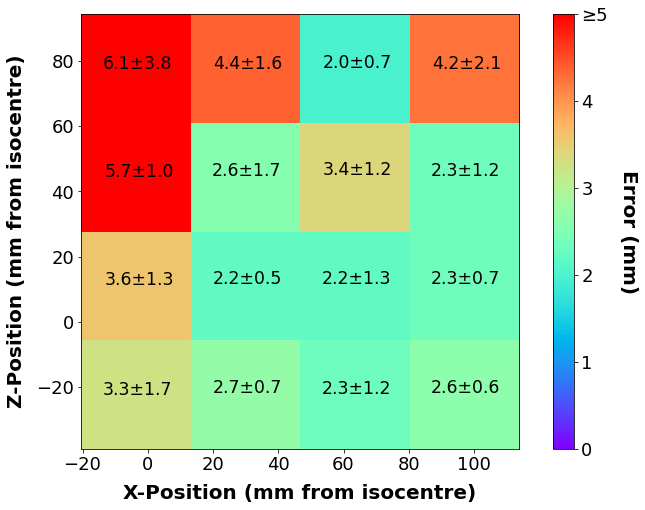

Tip Tracking Error @ Y = 45mm sequence SRI_Original, algorithm jpng


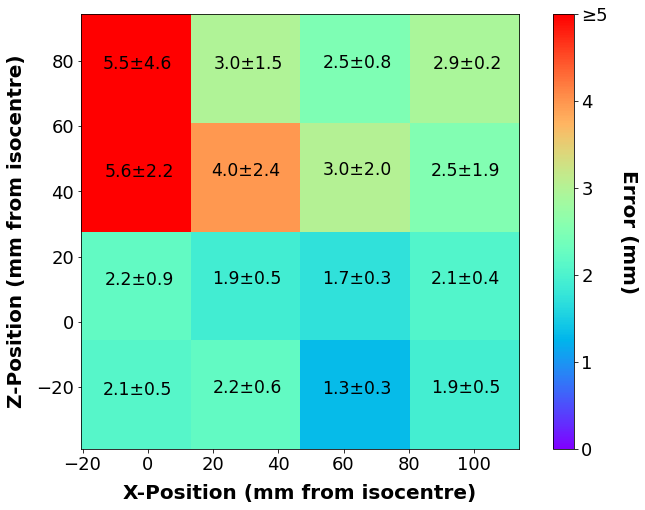

Tip Tracking Error @ Y = 45mm sequence FH512_noDither_gradSpoiled, algorithm centroid_around_peak


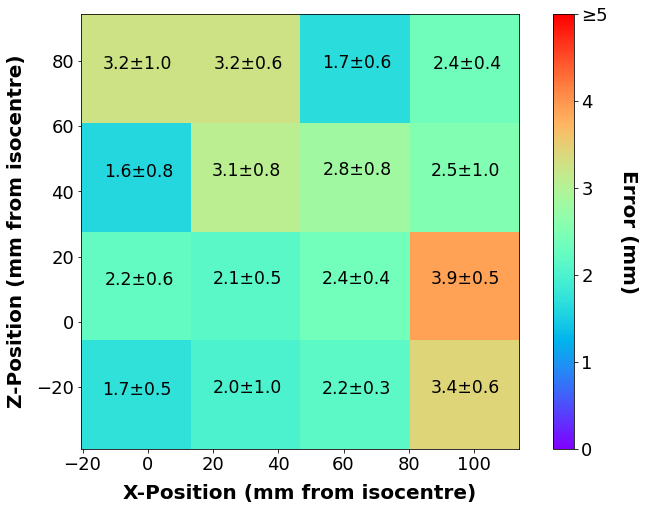

Tip Tracking Error @ Y = 45mm sequence FH512_noDither_gradSpoiled, algorithm jpng


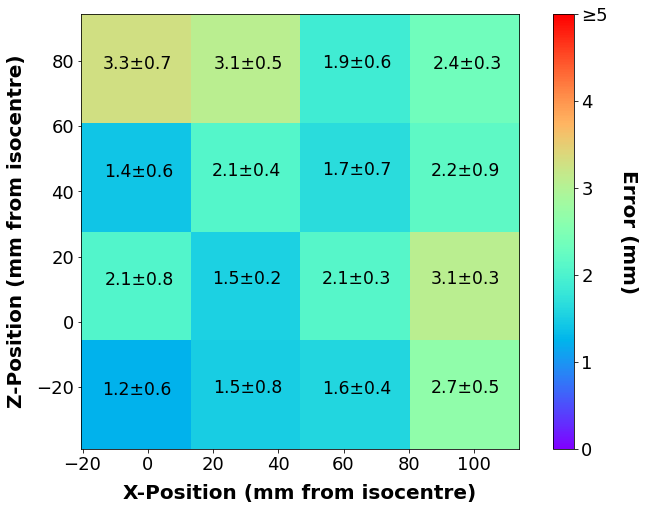

Error heatmaps for Y = 20mm
Tip Tracking Error @ Y = 20mm sequence SRI_Original, algorithm centroid_around_peak


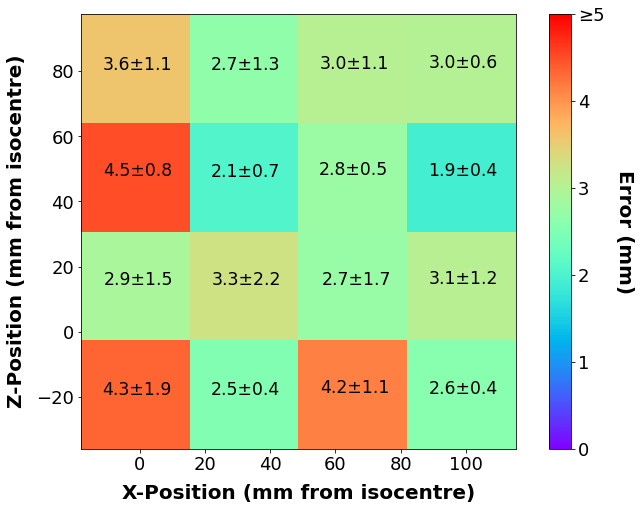

Tip Tracking Error @ Y = 20mm sequence SRI_Original, algorithm jpng


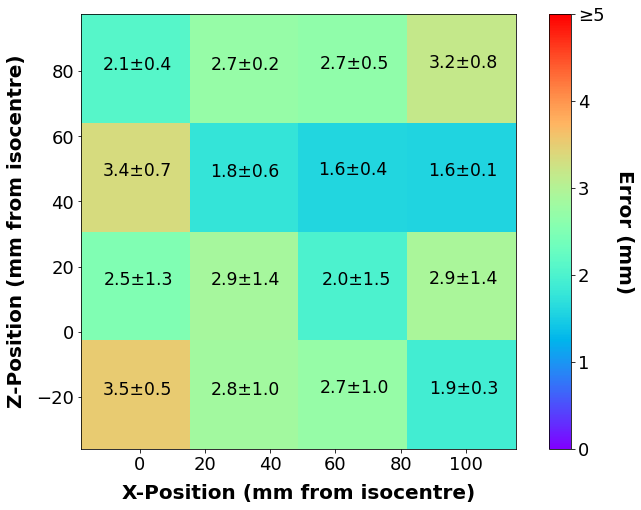

Tip Tracking Error @ Y = 20mm sequence FH512_noDither_gradSpoiled, algorithm centroid_around_peak


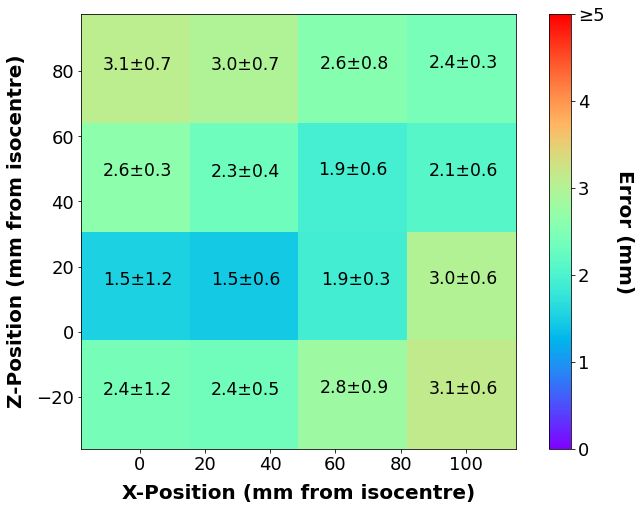

Tip Tracking Error @ Y = 20mm sequence FH512_noDither_gradSpoiled, algorithm jpng


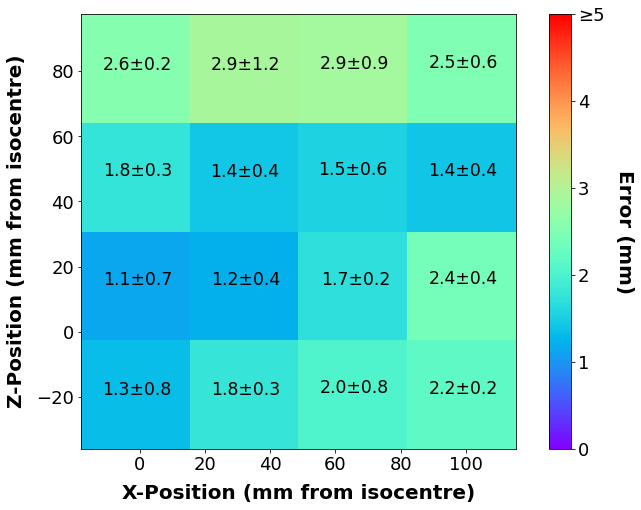

Error heatmaps for Y = -5mm
Tip Tracking Error @ Y = -5mm sequence SRI_Original, algorithm centroid_around_peak


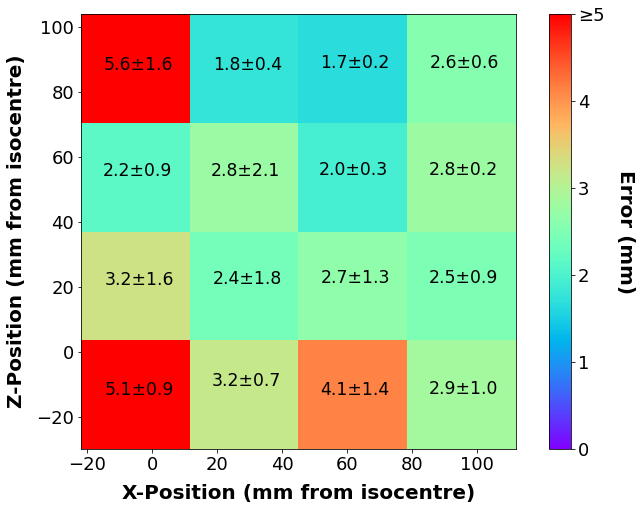

Tip Tracking Error @ Y = -5mm sequence SRI_Original, algorithm jpng


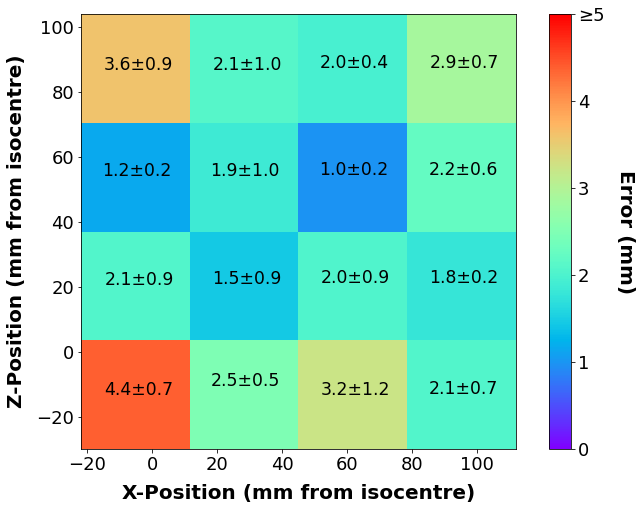

Tip Tracking Error @ Y = -5mm sequence FH512_noDither_gradSpoiled, algorithm centroid_around_peak


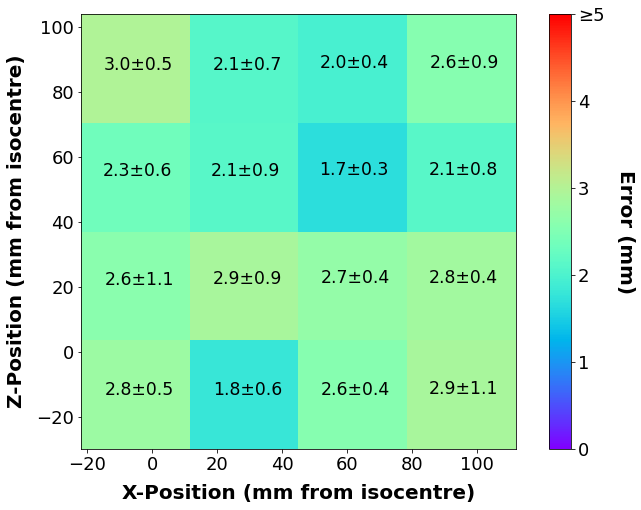

Tip Tracking Error @ Y = -5mm sequence FH512_noDither_gradSpoiled, algorithm jpng


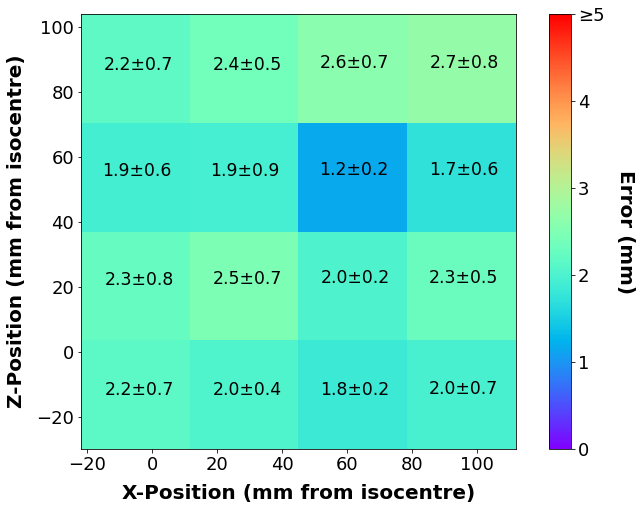

In [22]:
# Note this uses a different method to get the mean bias: use the subsequent code
for yloc in y_locations:
    print(f'Error heatmaps for {yloc.description}')
    for seq in sequences:
        for alg in algorithms:
            main_path = main_paths[yloc.in_suffix]
            sub_df = agg_df[(agg_df['Y_Loc']==yloc.in_suffix) & (agg_df['Sequence']==seq) & (agg_df['Algorithm']==alg)]
            # sub_df has all grid locations for all catheters for this combination of Y loc, sequence & algorithm
            # average the errors and GT_X,GT_Z for all catheters for each grid location
            grid_group_df = sub_df.groupby('Grid_Loc',as_index=False)
            # Mean bias and stdev by grid location using the cropped bias list
            bias_grid = grid_group_df.apply(lambda x: np.mean(np.concatenate(x['Biases_Crop'].values, axis=None)))
            stddev_grid = grid_group_df.apply(lambda x: np.std(np.concatenate(x['Biases_Crop'].values, axis=None)))
            gt_x = grid_group_df.mean()['GT_X'].values
            gt_z = grid_group_df.mean()['GT_Z'].values
            
            my_data = np.array([gt_x, gt_z, bias_grid.values]).T # reshaping from original code
            X = my_data[:, 0]
            Y = my_data[:, 1]
            biases = my_data[:, 2]
            
            # We'll plot the error along X & Z (where Z will be plotted on the Y-axis)
            heatmap = static_utils.nonuniform_imshow(gt_x, gt_z, bias_grid.values, stddev_grid.values, numeric=True)
            # Below is the original method:
            # heatmap = static_utils.nonuniform_imshow(X, Y, biases, stddev_grid.values, numeric=True)
            
            plt.gca().invert_yaxis()
            plt.xlabel('X-Position (mm from isocentre)', fontsize = 20, fontweight = 'bold', labelpad = 10)
            plt.ylabel('Z-Position (mm from isocentre)', fontsize = 20, fontweight = 'bold', labelpad = 10)
            plt.xticks(fontsize = 18)
            plt.yticks(fontsize = 18)
            print('Tip Tracking Error @ {2} sequence {0}, algorithm {1}'.format(seq, alg, yloc.description))
            cbar = plt.colorbar(heatmap)
            cbar.ax.set_yticklabels(['0', '1', '2', '3', '4', '\u2265' + '5'])
            cbar.ax.get_yaxis().labelpad = 30
            cbar.ax.tick_params(labelsize = 18)
            cbar.ax.set_ylabel('Error (mm)', rotation = 270, fontsize = 20, fontweight = 'bold')

            if not os.path.isdir('{0}'.format(heatmap_paths[yloc.in_suffix])):
                os.makedirs('{0}'.format(heatmap_paths[yloc.in_suffix]))

            plt.savefig('{0}{1}_{2}_crop_heatmap.png'.format(heatmap_paths[yloc.in_suffix], seq, alg), dpi=300)
            plt.show()
            # Below we save the tip errors from each catheter to hdf5 format
            #h5out = '{0}{3}_{1}_{2}.h5'.format(error_path, seq, alg, yloc.in_suffix)
            #with h5py.File(h5out, 'w', libver='latest') as f:
            #    print("Saving error data from each catheter to: " + h5out)
            #    for k, v in path_dct.items():
            #        expmt = pathlib.PurePath(k).parts[-1]
            #        name = 'static_err_' + seq + '_' + alg + '_' + expmt
            #        f.create_dataset(name, data=v[0])
            

Error heatmaps for Y = 45mm
shape of Z: (16,)
Tip Tracking Error @ Y = 45mm sequence SRI_Original, algorithm centroid_around_peak


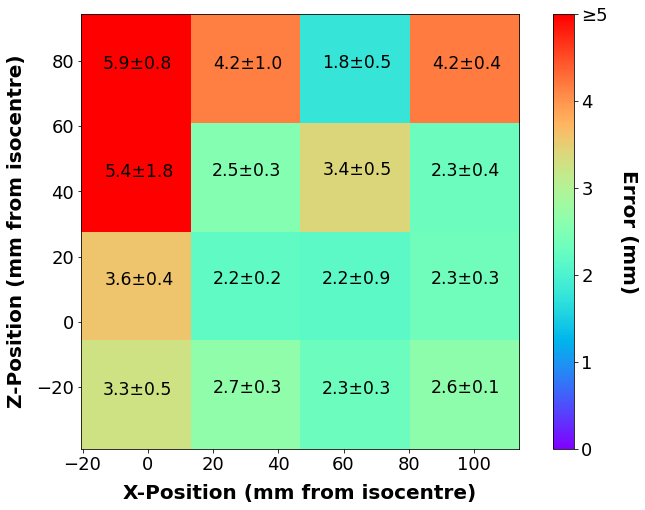

Saving error data from each catheter to: ../reports/export/static/Y0_SRI_Original_centroid_around_peak.h5
Error heatmaps for Y = 45mm
shape of Z: (16,)
Tip Tracking Error @ Y = 45mm sequence SRI_Original, algorithm jpng


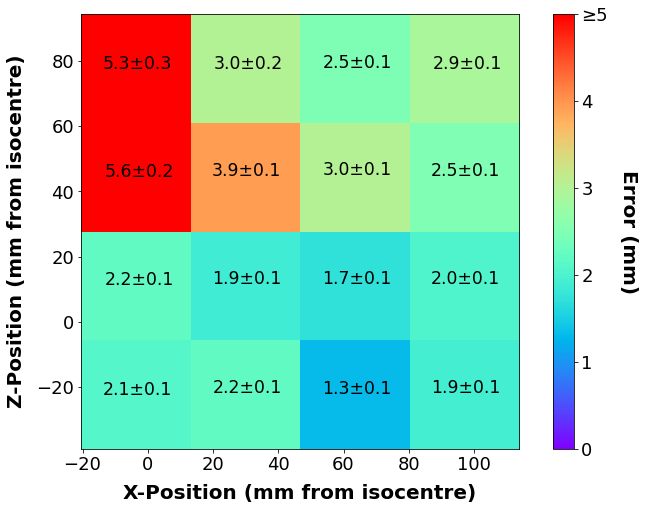

Saving error data from each catheter to: ../reports/export/static/Y0_SRI_Original_jpng.h5
Error heatmaps for Y = 45mm
shape of Z: (16,)
Tip Tracking Error @ Y = 45mm sequence FH512_noDither_gradSpoiled, algorithm centroid_around_peak


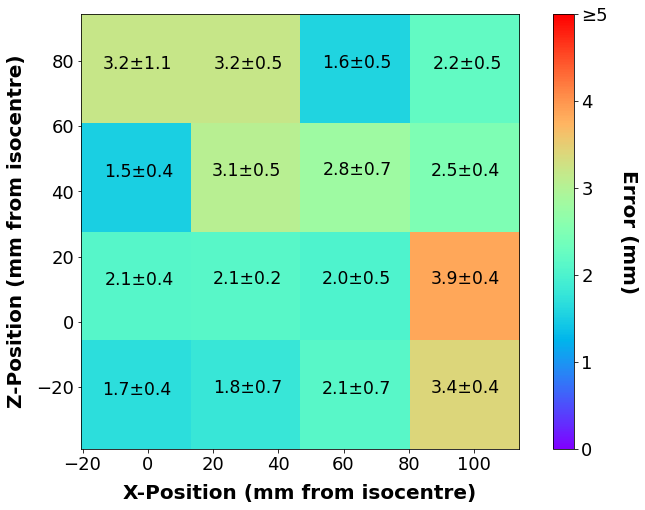

Saving error data from each catheter to: ../reports/export/static/Y0_FH512_noDither_gradSpoiled_centroid_around_peak.h5
Error heatmaps for Y = 45mm
shape of Z: (16,)
Tip Tracking Error @ Y = 45mm sequence FH512_noDither_gradSpoiled, algorithm jpng


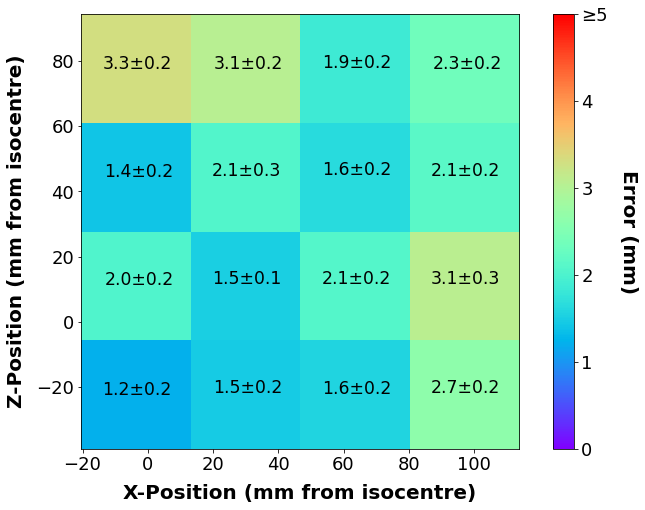

Saving error data from each catheter to: ../reports/export/static/Y0_FH512_noDither_gradSpoiled_jpng.h5
Error heatmaps for Y = 20mm
shape of Z: (16,)
Tip Tracking Error @ Y = 20mm sequence SRI_Original, algorithm centroid_around_peak


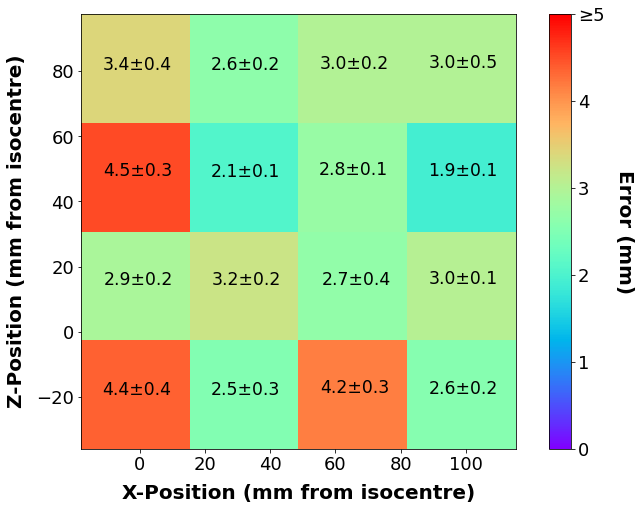

Saving error data from each catheter to: ../reports/export/static/Y1_SRI_Original_centroid_around_peak.h5
Error heatmaps for Y = 20mm
shape of Z: (16,)
Tip Tracking Error @ Y = 20mm sequence SRI_Original, algorithm jpng


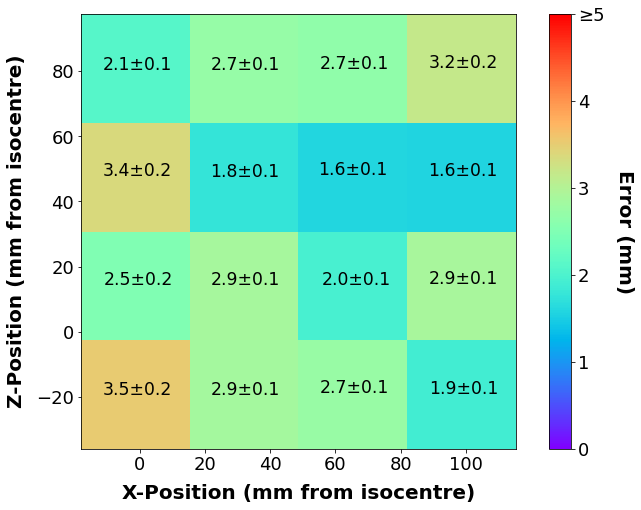

Saving error data from each catheter to: ../reports/export/static/Y1_SRI_Original_jpng.h5
Error heatmaps for Y = 20mm
shape of Z: (16,)
Tip Tracking Error @ Y = 20mm sequence FH512_noDither_gradSpoiled, algorithm centroid_around_peak


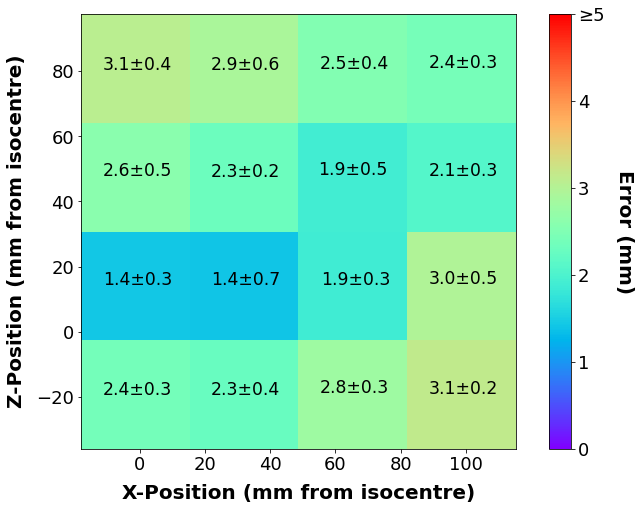

Saving error data from each catheter to: ../reports/export/static/Y1_FH512_noDither_gradSpoiled_centroid_around_peak.h5
Error heatmaps for Y = 20mm
shape of Z: (16,)
Tip Tracking Error @ Y = 20mm sequence FH512_noDither_gradSpoiled, algorithm jpng


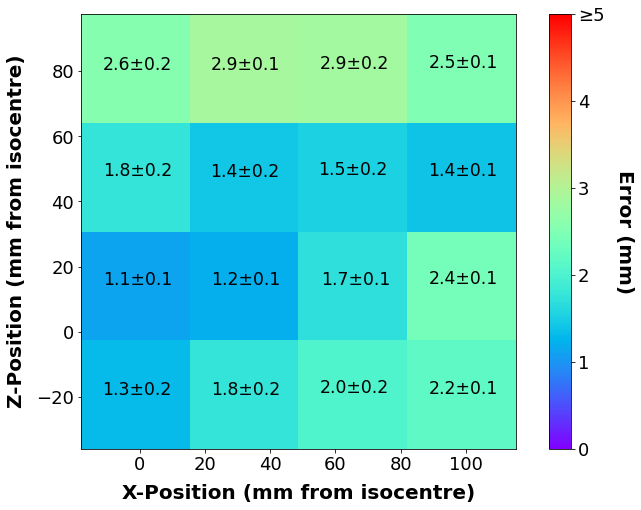

Saving error data from each catheter to: ../reports/export/static/Y1_FH512_noDither_gradSpoiled_jpng.h5
Error heatmaps for Y = -5mm
Adjusting for missing recording for SRI_Original, centroid_around_peak, Y2
shape of Z: (16,)
Tip Tracking Error @ Y = -5mm sequence SRI_Original, algorithm centroid_around_peak


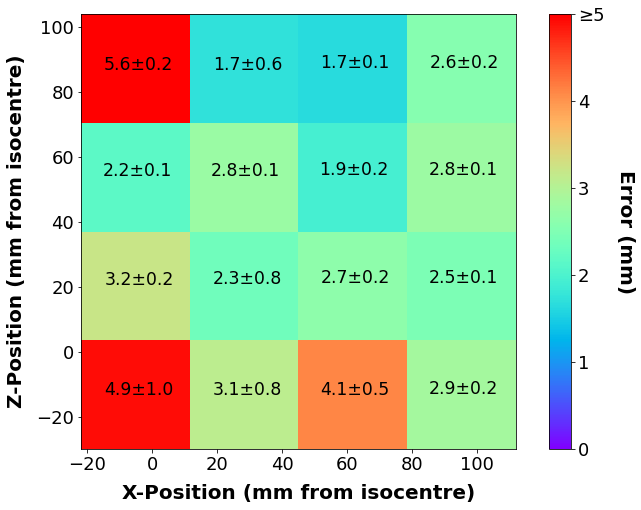

Saving error data from each catheter to: ../reports/export/static/Y2_SRI_Original_centroid_around_peak.h5
Error heatmaps for Y = -5mm
Adjusting for missing recording for SRI_Original, jpng, Y2
shape of Z: (16,)
Tip Tracking Error @ Y = -5mm sequence SRI_Original, algorithm jpng


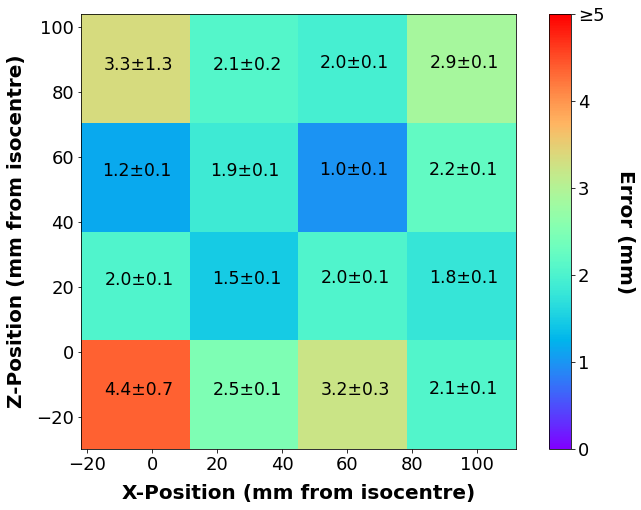

Saving error data from each catheter to: ../reports/export/static/Y2_SRI_Original_jpng.h5
Error heatmaps for Y = -5mm
shape of Z: (16,)
Tip Tracking Error @ Y = -5mm sequence FH512_noDither_gradSpoiled, algorithm centroid_around_peak


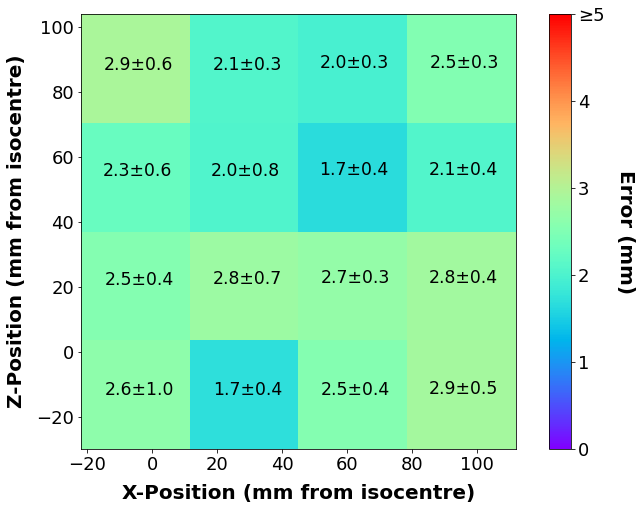

Saving error data from each catheter to: ../reports/export/static/Y2_FH512_noDither_gradSpoiled_centroid_around_peak.h5
Error heatmaps for Y = -5mm
shape of Z: (16,)
Tip Tracking Error @ Y = -5mm sequence FH512_noDither_gradSpoiled, algorithm jpng


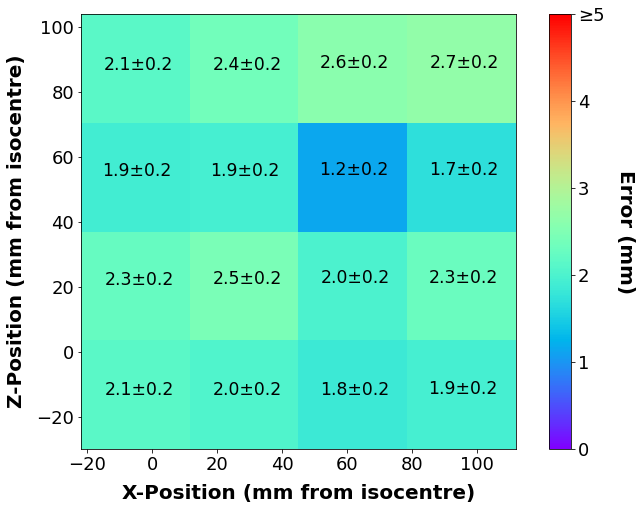

Saving error data from each catheter to: ../reports/export/static/Y2_FH512_noDither_gradSpoiled_jpng.h5


In [23]:
# Display heatmap error plots
for plot_combination in aggregate_plot:
    yloc = plot_combination['Y_Loc']
    print(f'Error heatmaps for {yloc.description}')
    seq = plot_combination['Sequence']
    alg = plot_combination['Algorithm']
    path_dct = plot_combination['Path_Dict']
    main_path = main_paths[yloc.in_suffix]
    # Average the error over catheters
    sum_all_caths = path_dct[main_path[0]][0] + path_dct[main_path[1]][0] + path_dct[main_path[2]][0]
    avg_all_caths = sum_all_caths / 3
    if seq == 'SRI_Original' and yloc.in_suffix == 'Y2':
        # A recording is missing - results in one invalid 0 mm error in the path_dct
        print(f'Adjusting for missing recording for {seq}, {alg}, {yloc.in_suffix}')
        avg_all_caths[1, 2] = avg_all_caths[1, 2] * 3/2.0 # recover total sum, then divide by 2 for mean
    avg_err = avg_all_caths[:, 2]
    stddev = np.sqrt(sum_all_caths[:, 3])

    my_data = np.array([avg_all_caths[:, 0], avg_all_caths[:, 1], avg_err]).T

    X = my_data[:, 0]
    Y = my_data[:, 1]
    Z = my_data[:, 2]
    print(f'shape of Z: {np.shape(Z)}')

    heatmap = static_utils.nonuniform_imshow(X, Y, Z, stddev, numeric=True)
    plt.gca().invert_yaxis()
    plt.xlabel('X-Position (mm from isocentre)', fontsize = 20, fontweight = 'bold', labelpad = 10)
    plt.ylabel('Z-Position (mm from isocentre)', fontsize = 20, fontweight = 'bold', labelpad = 10)
    plt.xticks(fontsize = 18)
    plt.yticks(fontsize = 18)
    print('Tip Tracking Error @ {2} sequence {0}, algorithm {1}'.format(seq, alg, yloc.description))
    cbar = plt.colorbar(heatmap)
    cbar.ax.set_yticklabels(['0', '1', '2', '3', '4', '\u2265' + '5'])
    cbar.ax.get_yaxis().labelpad = 30
    cbar.ax.tick_params(labelsize = 18)
    cbar.ax.set_ylabel('Error (mm)', rotation = 270, fontsize = 20, fontweight = 'bold')

    if not os.path.isdir('{0}'.format(heatmap_paths[yloc.in_suffix])):
        os.makedirs('{0}'.format(heatmap_paths[yloc.in_suffix]))

    plt.savefig('{0}{1}_{2}_heatmap.png'.format(heatmap_paths[yloc.in_suffix], seq, alg), dpi=300)
    plt.show()
    # Below we save the tip errors from each catheter to hdf5 format
    h5out = '{0}{3}_{1}_{2}.h5'.format(error_path, seq, alg, yloc.in_suffix)
    with h5py.File(h5out, 'w', libver='latest') as f:
        print("Saving error data from each catheter to: " + h5out)
        for k, v in path_dct.items():
            expmt = pathlib.PurePath(k).parts[-1]
            name = 'static_err_' + seq + '_' + alg + '_' + expmt
            f.create_dataset(name, data=v[0])

# Comparisons across Sequences and Algorithms
We plan to compare tip errors from the JPNG and CAP peak-finding algorithms, for each sequence. Then we will compare tip errrors from both the HM & 3P sequences, with both JPNG and CAP algorithms. This will result in four comparisons, so we will use a Bonferroni adjustment for the p-value.

In [24]:
p_val_adj = 0.05 / 4

In [25]:
p_val_adj

0.0125

In [26]:
agg_df

,Y_Loc,Sequence,Algorithm,Catheter,Grid_Loc,Mean_Bias,Biases,Variance,Count,GT_X,GT_Z,Biases_Crop
0,Y0,SRI_Original,centroid_around_peak,C222,1,1.970112,"[1.9833520602399075, 2.0714497764852036, 1.812...",0.003940,337.0,-2.609326,-21.936268,"[1.9833520602399075, 2.0714497764852036, 1.812..."
1,Y0,SRI_Original,centroid_around_peak,C222,2,3.175268,"[3.090043110615727, 3.126779341178156, 3.09207...",0.003491,339.0,30.943948,-22.098604,"[3.090043110615727, 3.126779341178156, 3.09207..."
2,Y0,SRI_Original,centroid_around_peak,C222,3,0.948233,"[1.1408342182641895, 0.9749383302433562, 1.095...",0.096054,346.0,64.474602,-22.240331,"[1.1408342182641895, 0.9749383302433562, 1.095..."
3,Y0,SRI_Original,centroid_around_peak,C222,4,2.855528,"[2.925006311464213, 2.7307822863905487, 2.9305...",0.002422,340.0,97.597368,-21.155930,"[2.925006311464213, 2.7307822863905487, 2.9305..."
4,Y0,SRI_Original,centroid_around_peak,C222,5,2.708824,"[2.7734128719347777, 2.6661149919671536, 2.653...",0.003078,356.0,98.385867,11.853434,"[2.7734128719347777, 2.6661149919671536, 2.653..."
...,...,...,...,...,...,...,...,...,...,...,...,...
571,Y2,FH512_noDither_gradSpoiled,jpng,C306,12,1.977405,"[2.0967337921131093, 2.098694082491882, 2.1577...",0.003875,177.0,96.287750,49.580823,"[2.0967337921131093, 2.098694082491882, 2.1577..."
572,Y2,FH512_noDither_gradSpoiled,jpng,C306,13,1.635901,"[1.7734196051076967, 1.7106319403999157, 1.726...",0.005339,182.0,96.215453,82.892297,"[1.7734196051076967, 1.7106319403999157, 1.726..."
573,Y2,FH512_noDither_gradSpoiled,jpng,C306,14,1.933651,"[2.0415259202574005, 2.3109337099813385, 2.288...",0.010329,179.0,62.903314,82.553024,"[2.0415259202574005, 2.3109337099813385, 2.288..."
574,Y2,FH512_noDither_gradSpoiled,jpng,C306,15,1.887507,"[2.0088087950072353, 2.0332241908185344, 2.152...",0.004623,180.0,29.271801,82.425704,"[2.0088087950072353, 2.0332241908185344, 2.152..."


In [27]:
agg_df[agg_df['Count']==0] # Missed recording from a sequence at one grid location

,Y_Loc,Sequence,Algorithm,Catheter,Grid_Loc,Mean_Bias,Biases,Variance,Count,GT_X,GT_Z,Biases_Crop


In [28]:
# Missing recording for this combination!
#invalid_rows = agg_df[(agg_df['Y_Loc']=='Y2') & (agg_df['Sequence']=='SRI_Original') & (agg_df['Catheter']=='C306') & (agg_df['Grid_Loc']==2)].index

In [29]:
agg_df = agg_df.drop(agg_df[agg_df['Count']==0].index)

In [30]:
agg_df[agg_df['Count']==0]

,Y_Loc,Sequence,Algorithm,Catheter,Grid_Loc,Mean_Bias,Biases,Variance,Count,GT_X,GT_Z,Biases_Crop


In [31]:
agg_df  # each row contains the error (bias) and variance for one multi-second recording
        # of one sequence, from one catheter, at one location, processed with one algorithm

,Y_Loc,Sequence,Algorithm,Catheter,Grid_Loc,Mean_Bias,Biases,Variance,Count,GT_X,GT_Z,Biases_Crop
0,Y0,SRI_Original,centroid_around_peak,C222,1,1.970112,"[1.9833520602399075, 2.0714497764852036, 1.812...",0.003940,337.0,-2.609326,-21.936268,"[1.9833520602399075, 2.0714497764852036, 1.812..."
1,Y0,SRI_Original,centroid_around_peak,C222,2,3.175268,"[3.090043110615727, 3.126779341178156, 3.09207...",0.003491,339.0,30.943948,-22.098604,"[3.090043110615727, 3.126779341178156, 3.09207..."
2,Y0,SRI_Original,centroid_around_peak,C222,3,0.948233,"[1.1408342182641895, 0.9749383302433562, 1.095...",0.096054,346.0,64.474602,-22.240331,"[1.1408342182641895, 0.9749383302433562, 1.095..."
3,Y0,SRI_Original,centroid_around_peak,C222,4,2.855528,"[2.925006311464213, 2.7307822863905487, 2.9305...",0.002422,340.0,97.597368,-21.155930,"[2.925006311464213, 2.7307822863905487, 2.9305..."
4,Y0,SRI_Original,centroid_around_peak,C222,5,2.708824,"[2.7734128719347777, 2.6661149919671536, 2.653...",0.003078,356.0,98.385867,11.853434,"[2.7734128719347777, 2.6661149919671536, 2.653..."
...,...,...,...,...,...,...,...,...,...,...,...,...
571,Y2,FH512_noDither_gradSpoiled,jpng,C306,12,1.977405,"[2.0967337921131093, 2.098694082491882, 2.1577...",0.003875,177.0,96.287750,49.580823,"[2.0967337921131093, 2.098694082491882, 2.1577..."
572,Y2,FH512_noDither_gradSpoiled,jpng,C306,13,1.635901,"[1.7734196051076967, 1.7106319403999157, 1.726...",0.005339,182.0,96.215453,82.892297,"[1.7734196051076967, 1.7106319403999157, 1.726..."
573,Y2,FH512_noDither_gradSpoiled,jpng,C306,14,1.933651,"[2.0415259202574005, 2.3109337099813385, 2.288...",0.010329,179.0,62.903314,82.553024,"[2.0415259202574005, 2.3109337099813385, 2.288..."
574,Y2,FH512_noDither_gradSpoiled,jpng,C306,15,1.887507,"[2.0088087950072353, 2.0332241908185344, 2.152...",0.004623,180.0,29.271801,82.425704,"[2.0088087950072353, 2.0332241908185344, 2.152..."


## JPNG vs CAP
### HM
Compare JPNG and CAP algorithms in the hadamard-multiplexed sequence

In [32]:
hm_df = agg_df[agg_df['Sequence']=='FH512_noDither_gradSpoiled']

In [33]:
hm_cap_errors = hm_df[hm_df['Algorithm']=='centroid_around_peak']['Biases'].apply(pd.Series).values.ravel()

In [34]:
hm_cap_errors

array([0.73024172, 0.75007554, 0.92962969, ...,        nan,        nan,
              nan])

In [35]:
hm_jpng_errors = hm_df[hm_df['Algorithm']=='jpng']['Biases'].apply(pd.Series).values.ravel()

In [36]:
hm_jpng_errors

array([0.51057485, 0.68020348, 0.65147419, ...,        nan,        nan,
              nan])

In [37]:
np.isnan(hm_jpng_errors).sum() / len(hm_jpng_errors)

0.03313707729468599

In [38]:
np.array_equal(np.isnan(hm_jpng_errors),np.isnan(hm_cap_errors))

True

In [39]:
# NaNs in our tip error are likely due to recordings for multiple coils finishing at slightly different times
# They match between the arrays, so remove them
hm_cap_errors = hm_cap_errors[~np.isnan(hm_cap_errors)]
hm_jpng_errors = hm_jpng_errors[~np.isnan(hm_jpng_errors)]

In [40]:
len(hm_cap_errors)

25618

In [41]:
len(hm_jpng_errors)

25618

In [42]:
w, p = stats.wilcoxon(x=hm_jpng_errors,y=hm_cap_errors,alternative='less')

In [43]:
p

0.0

In [44]:
import sys
sys.path.append('../')

In [45]:
import Invivo_Tracking.displacement_utils as disp_utils

/home/lbiswas/miniconda3/envs/mr-track/lib/python3.8/site-packages/scipy/stats/morestats.py:1676: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Static Experiment HM Sequence: CAP vs JPNG Tip Error Wilcoxon one-tailed


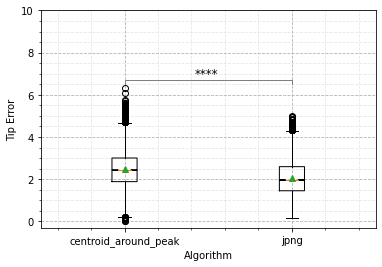

In [46]:
plot, test = disp_utils.plot_displacement_boxplot([hm_cap_errors,hm_jpng_errors], show_scatter=False,\
                                                  y_label='Tip Error',set_ymax=10, p_value=p_val_adj, alternative='greater')
print('Static Experiment HM Sequence: CAP vs JPNG Tip Error '+ test)
plot.savefig('../reports/figures/static/HM-capVsJpng-tipErr.pdf',dpi=600)
plot.show()

#### HM mean bias comparison
Compare JPNG and CAP algorithms in the hadamard-multiplexed sequence, using the mean biases from each 3d grid location - this should be an average of the biases from each catheter:

In [47]:
hm_cap_mean_errors = hm_df[hm_df['Algorithm']=='centroid_around_peak']['Mean_Bias'].values

In [48]:
hm_jpng_mean_errors = hm_df[hm_df['Algorithm']=='jpng']['Mean_Bias'].values

In [49]:
len(hm_cap_mean_errors)

144

In [50]:
len(hm_jpng_mean_errors)

144

In [51]:
hm_cap_mean_errors = []
hm_jpng_mean_errors = []

In [52]:
hm_df[(hm_df['Algorithm']=='centroid_around_peak') & (hm_df['Y_Loc']=='Y0') & (hm_df['Grid_Loc']==1)]

,Y_Loc,Sequence,Algorithm,Catheter,Grid_Loc,Mean_Bias,Biases,Variance,Count,GT_X,GT_Z,Biases_Crop
96,Y0,FH512_noDither_gradSpoiled,centroid_around_peak,C222,1,1.134695,"[0.7302417240937265, 0.7500755356069915, 0.929...",0.015880,181.0,-2.609326,-21.936268,"[0.7302417240937265, 0.7500755356069915, 0.929..."
112,Y0,FH512_noDither_gradSpoiled,centroid_around_peak,C231,1,1.836971,"[1.011415294950236, 1.7755828482800864, 1.6729...",0.027093,183.0,-4.837048,-19.732062,"[1.011415294950236, 1.7755828482800864, 1.6729..."
128,Y0,FH512_noDither_gradSpoiled,centroid_around_peak,C306,1,2.106907,"[1.4787031727265678, 1.0285377346011988, 1.376...",0.112071,184.0,-4.117354,-25.266704,"[1.4787031727265678, 1.0285377346011988, 1.376..."


In [53]:
y_locs = hm_df['Y_Loc'].unique() # unique(): returned in order of appearance

In [54]:
grid_locs = hm_df['Grid_Loc'].unique()

When comparing the two algorithms, the number of samples is the same, so we can average the Mean_Bias column

In [55]:
for y in y_locs:
    for g in grid_locs:
        cap_mean = hm_df[(hm_df['Algorithm']=='centroid_around_peak') & (hm_df['Y_Loc']==y) & (hm_df['Grid_Loc']==g)]['Mean_Bias'].mean()
        jpng_mean = hm_df[(hm_df['Algorithm']=='jpng') & (hm_df['Y_Loc']==y) & (hm_df['Grid_Loc']==g)]['Mean_Bias'].mean()
        hm_cap_mean_errors.append(cap_mean)
        hm_jpng_mean_errors.append(jpng_mean)

Sanity check that we now have the correct number of 3d locations:

In [56]:
len(hm_cap_mean_errors)

48

In [57]:
np.mean(hm_cap_mean_errors)

2.4049888228245675

In [58]:
np.std(hm_cap_mean_errors)

0.5549971837619325

In [59]:
len(hm_jpng_mean_errors)

48

In [60]:
np.mean(hm_jpng_mean_errors)

2.0347038503902968

In [61]:
np.std(hm_jpng_mean_errors)

0.5361689098036709

In [62]:
w, p = stats.wilcoxon(x=hm_jpng_mean_errors,y=hm_cap_mean_errors,alternative='less')

In [63]:
p

1.530169880194031e-06

Static Experiment HM Sequence: CAP vs JPNG Tip Error


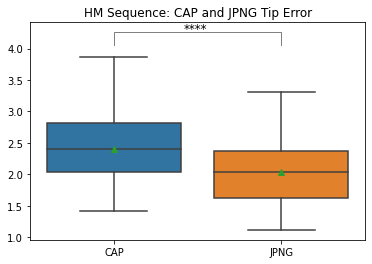

In [64]:
ax = sns.boxplot(data=[hm_cap_mean_errors,hm_jpng_mean_errors],orient='v',showmeans=True)
print('Static Experiment HM Sequence: CAP vs JPNG Tip Error')
max_y = max(np.max(hm_cap_mean_errors),np.max(hm_jpng_mean_errors))
if p < p_val_adj: # draw a significance line
    star_str = disp_utils.get_p_stars(p)
    starline_y = max_y
    ax.plot([0, 0, 1, 1], [starline_y+0.2, starline_y+0.4, starline_y+0.4, starline_y+0.2], linewidth=1, color='grey')
    ax.text(0.49, starline_y+0.4, star_str, ha='center', fontsize=12)
ax.set_title('HM Sequence: CAP and JPNG Tip Error')
ax.set_xticklabels(['CAP','JPNG'])
plt.savefig('../reports/figures/static/HM-capVsJpng-meantipErr.pdf',dpi=600)
plt.show()

### 3P Sequence
Compare JPNG and CAP algorithms in the three-projection sequence

In [65]:
proj_df = agg_df[agg_df['Sequence']=='SRI_Original']

In [66]:
proj_cap_errors = proj_df[proj_df['Algorithm']=='centroid_around_peak']['Biases'].apply(pd.Series).values.ravel()

In [67]:
proj_jpng_errors = proj_df[proj_df['Algorithm']=='jpng']['Biases'].apply(pd.Series).values.ravel()

In [68]:
proj_cap_errors

array([1.98335206, 2.07144978, 1.81200858, ...,        nan,        nan,
              nan])

In [69]:
np.isnan(proj_cap_errors).sum() / len(proj_cap_errors)

0.03453409335762277

In [70]:
np.array_equal(np.isnan(proj_cap_errors),np.isnan(proj_jpng_errors))

True

In [71]:
# NaNs in our tip error are likely due to recordings for multiple coils finishing at slightly different times
# They match between the arrays, so remove them
proj_cap_errors = proj_cap_errors[~np.isnan(proj_cap_errors)]
proj_jpng_errors = proj_jpng_errors[~np.isnan(proj_jpng_errors)]

In [72]:
w, p = stats.wilcoxon(x=proj_jpng_errors,y=proj_cap_errors,alternative='less')

In [73]:
p

0.0

/home/lbiswas/miniconda3/envs/mr-track/lib/python3.8/site-packages/scipy/stats/morestats.py:1676: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Static Experiment 3P Sequence: CAP vs JPNG Tip Error Wilcoxon one-tailed


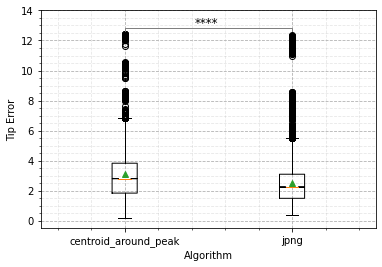

In [74]:
plot, test = disp_utils.plot_displacement_boxplot([proj_cap_errors,proj_jpng_errors], show_scatter=False,\
                                                  y_label='Tip Error',set_ymax=14, p_value=p_val_adj, alternative='greater')
print('Static Experiment 3P Sequence: CAP vs JPNG Tip Error '+ test)
plot.savefig('../reports/figures/static/3P-capVsJpng-tipErr.pdf',dpi=600)
plot.show()

#### 3P mean bias comparison
Compare JPNG and CAP algorithms in the three-projection sequence, using the mean biases from each 3d grid location - this should be an average of the biases from each catheter:

In [75]:
proj_cap_mean_errors = []
proj_jpng_mean_errors = []

In [76]:
for y in y_locs:
    for g in grid_locs:
        cap_mean = proj_df[(proj_df['Algorithm']=='centroid_around_peak') & (proj_df['Y_Loc']==y) & (proj_df['Grid_Loc']==g)]['Mean_Bias'].mean()
        jpng_mean = proj_df[(proj_df['Algorithm']=='jpng') & (proj_df['Y_Loc']==y) & (proj_df['Grid_Loc']==g)]['Mean_Bias'].mean()
        proj_cap_mean_errors.append(cap_mean)
        proj_jpng_mean_errors.append(jpng_mean)

In [77]:
w, p = stats.wilcoxon(x=proj_jpng_mean_errors,y=proj_cap_mean_errors,alternative='less')

In [78]:
p

9.725942006084667e-07

In [79]:
np.mean(proj_cap_mean_errors)

3.0547507652106027

In [80]:
np.std(proj_cap_mean_errors)

1.0067931077309

In [81]:
np.mean(proj_jpng_mean_errors)

2.509016114186541

In [82]:
np.std(proj_jpng_mean_errors)

0.9281836374657682

Static Experiment 3P Sequence: CAP vs JPNG Tip Error


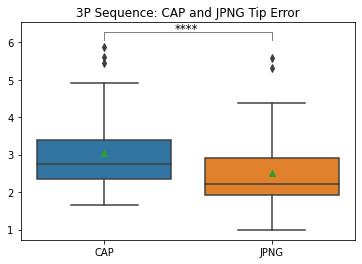

In [83]:
ax = sns.boxplot(data=[proj_cap_mean_errors,proj_jpng_mean_errors],orient='v',showmeans=True)
print('Static Experiment 3P Sequence: CAP vs JPNG Tip Error')
max_y = max(np.max(proj_cap_mean_errors),np.max(proj_jpng_mean_errors))
if p < p_val_adj: # draw a significance line
    star_str = disp_utils.get_p_stars(p)
    starline_y = max_y
    ax.plot([0, 0, 1, 1], [starline_y+0.2, starline_y+0.4, starline_y+0.4, starline_y+0.2], linewidth=1, color='grey')
    ax.text(0.49, starline_y+0.4, star_str, ha='center', fontsize=12)
ax.set_title('3P Sequence: CAP and JPNG Tip Error')
ax.set_xticklabels(['CAP','JPNG'])
plt.savefig('../reports/figures/static/3P-capVsJpng-meantipErr.pdf',dpi=600)
plt.show()

## HM vs 3P
### JPNG
Compare tip errors from hadamard and three-projection sequences for JPNG algorithm.

In [84]:
jpng_df = agg_df[agg_df['Algorithm']=='jpng'].copy()

We're missing a recording from one catheter & location combination from the 3P sequence:
- Y_Loc: Y2
- Catheter: C306
- Grid_Loc: 2

To do a paired comparison, we should remove the matching recording from the HM sequence.

In [85]:
missing_match = jpng_df[(jpng_df['Y_Loc']=='Y2') & (jpng_df['Sequence']=='FH512_noDither_gradSpoiled') & \
                       (jpng_df['Catheter']=='C306') & (jpng_df['Grid_Loc']==2)].index

In [86]:
jpng_df = jpng_df.drop(missing_match)

In [87]:
jpng_df['Biases_Crop'] = jpng_df['Biases'] # Will crop this bias list to the smaller sample size

In [88]:
nan_tails = jpng_df.apply(lambda x: check_nans(x['Biases']), axis=1)

In [89]:
np.all(nan_tails)

True

In [90]:
jpng_df['Biases_Crop'] = jpng_df.apply(lambda x: crop_tails(x['Biases']),axis=1)

In [91]:
#crop_bias_list(jpng_df.iloc[0]['Biases'],'Y0',1,'C222','FH512_noDither_gradSpoiled',jpng_df)

In [92]:
jpng_df['Biases_Crop'] = jpng_df.apply(lambda x: x['Biases_Crop'] if x['Sequence'] != 'SRI_Original' else \
                                       crop_bias_list(x['Biases_Crop'], x['Y_Loc'], x['Grid_Loc'], \
                                                      x['Catheter'],'FH512_noDither_gradSpoiled', jpng_df), \
                                       axis=1)

*INFO* y-loc Y0, grid-loc 1, cathC222 - cropping from 337 to 181
*INFO* y-loc Y0, grid-loc 1, cathC222 - cropping from 337 to 181
*INFO* y-loc Y0, grid-loc 2, cathC222 - cropping from 339 to 182
*INFO* y-loc Y0, grid-loc 3, cathC222 - cropping from 346 to 181
*INFO* y-loc Y0, grid-loc 4, cathC222 - cropping from 340 to 183
*INFO* y-loc Y0, grid-loc 5, cathC222 - cropping from 356 to 177
*INFO* y-loc Y0, grid-loc 6, cathC222 - cropping from 334 to 174
*INFO* y-loc Y0, grid-loc 7, cathC222 - cropping from 333 to 178
*INFO* y-loc Y0, grid-loc 8, cathC222 - cropping from 345 to 174
*INFO* y-loc Y0, grid-loc 9, cathC222 - cropping from 353 to 172
*INFO* y-loc Y0, grid-loc 10, cathC222 - cropping from 356 to 181
*INFO* y-loc Y0, grid-loc 11, cathC222 - cropping from 348 to 173
*INFO* y-loc Y0, grid-loc 12, cathC222 - cropping from 357 to 179
*INFO* y-loc Y0, grid-loc 13, cathC222 - cropping from 355 to 181
*INFO* y-loc Y0, grid-loc 14, cathC222 - cropping from 336 to 182
*INFO* y-loc Y0, gri

In [93]:
jpng_HM_errors = jpng_df[jpng_df['Sequence']=='FH512_noDither_gradSpoiled']['Biases_Crop'].apply(pd.Series).values.ravel()

In [94]:
jpng_3P_errors = jpng_df[jpng_df['Sequence']=='SRI_Original']['Biases_Crop'].apply(pd.Series).values.ravel()

In [95]:
len(jpng_HM_errors)

26312

In [96]:
len(jpng_3P_errors)

26312

In [97]:
np.isnan(jpng_3P_errors).sum()

869

In [98]:
np.isnan(jpng_HM_errors).sum()

869

In [99]:
np.isnan(jpng_HM_errors).sum() / len(jpng_HM_errors)

0.03302675585284281

In [100]:
np.array_equal(np.isnan(jpng_HM_errors),np.isnan(jpng_3P_errors))

True

In [101]:
jpng_HM_errors = jpng_HM_errors[~np.isnan(jpng_HM_errors)]
jpng_3P_errors = jpng_3P_errors[~np.isnan(jpng_3P_errors)]

In [102]:
len(jpng_HM_errors)

25443

In [103]:
len(jpng_3P_errors)

25443

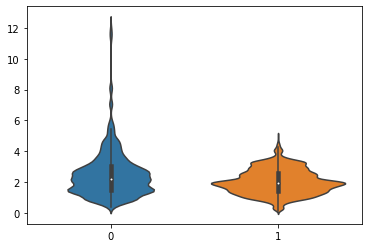

In [104]:
sns.violinplot(data=[jpng_3P_errors, jpng_HM_errors],orient='v')

Mann-Whitney U tests for independent measures: skip this and do the Wilcoxon test

In [105]:
u, p = stats.mannwhitneyu(jpng_HM_errors,jpng_3P_errors,alternative='less')

In [106]:
p

1.0702780987844411e-224

In [107]:
w, p = stats.wilcoxon(x=jpng_HM_errors,y=jpng_3P_errors,alternative='less')

In [108]:
p

0.0

Static Experiment JPNG Algorithm: 3P and HM Tip Error


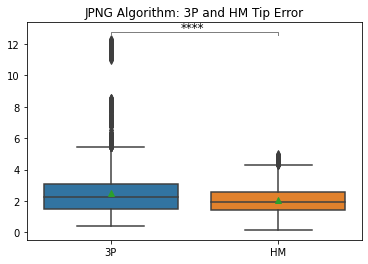

In [109]:
ax = sns.boxplot(data=[jpng_3P_errors,jpng_HM_errors],orient='v',showmeans=True)
print('Static Experiment JPNG Algorithm: 3P and HM Tip Error')
max_y = max(np.max(jpng_3P_errors),np.max(jpng_HM_errors))
if p < p_val_adj: # draw a significance line
    star_str = disp_utils.get_p_stars(p)
    starline_y = max_y
    ax.plot([0, 0, 1, 1], [starline_y+0.2, starline_y+0.4, starline_y+0.4, starline_y+0.2], linewidth=1, color='grey')
    ax.text(0.49, starline_y+0.5, star_str, ha='center', fontsize=12)
ax.set_title('JPNG Algorithm: 3P and HM Tip Error')
ax.set_xticklabels(['3P','HM'])
plt.savefig('../reports/figures/static/JPNG-3PvsHM-boxplot.pdf',dpi=600)
plt.show()

#### JPNG: compare the means 
Compare mean tip errors from hadamard and three-projection sequences for JPNG algorithm: get the means from each 3d grid location, from all catheters, using Mean_Bias

In [110]:
jpng_3P_mean_errors = []
jpng_HM_mean_errors = []
for y in y_locs:
    for g in grid_locs:
        proj_biases = jpng_df[(jpng_df['Sequence']=='SRI_Original') & (jpng_df['Y_Loc']==y) & (jpng_df['Grid_Loc']==g)]['Mean_Bias'].ravel()
        hm_biases = jpng_df[(jpng_df['Sequence']=='FH512_noDither_gradSpoiled') & (jpng_df['Y_Loc']==y) & (jpng_df['Grid_Loc']==g)]['Mean_Bias'].ravel()
        proj_biases = proj_biases[~np.isnan(proj_biases)]
        hm_biases = hm_biases[~np.isnan(hm_biases)]
        jpng_3P_mean_errors.append(np.mean(proj_biases))
        jpng_HM_mean_errors.append(np.mean(hm_biases))

In [111]:
len(jpng_3P_mean_errors)

48

In [112]:
np.mean(jpng_3P_mean_errors)

2.509016114186541

In [113]:
np.std(jpng_3P_mean_errors)

0.9281836374657682

In [114]:
np.mean(jpng_HM_mean_errors)

2.0296185492319068

In [115]:
np.std(jpng_HM_mean_errors)

0.537310290353905

In [116]:
w, p = stats.wilcoxon(x=jpng_HM_mean_errors,y=jpng_3P_mean_errors,alternative='less')

In [117]:
p

0.0022481714493689524

In [118]:
p_val_adj

0.0125

Static Experiment JPNG Algorithm: 3P and HM Mean Tip Error


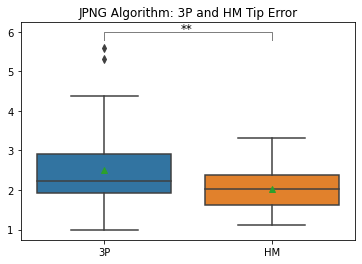

In [119]:
ax = sns.boxplot(data=[jpng_3P_mean_errors,jpng_HM_mean_errors],orient='v',showmeans=True)
print('Static Experiment JPNG Algorithm: 3P and HM Mean Tip Error')
max_y = max(np.max(jpng_3P_mean_errors),np.max(jpng_HM_mean_errors))
if p < p_val_adj: # draw a significance line
    star_str = disp_utils.get_p_stars(p)
    starline_y = max_y
    ax.plot([0, 0, 1, 1], [starline_y+0.2, starline_y+0.4, starline_y+0.4, starline_y+0.2], linewidth=1, color='grey')
    ax.text(0.49, starline_y+0.4, star_str, ha='center', fontsize=12)
ax.set_title('JPNG Algorithm: 3P and HM Tip Error')
ax.set_xticklabels(['3P','HM'])
plt.savefig('../reports/figures/static/JPNG-3PvsHM-mean_boxplot.pdf',dpi=600)
plt.show()

## CAP
Compare tip errors from hadamard and three-projection sequences for the centroid-around-peak algorithm.

In [120]:
cap_df = agg_df[agg_df['Algorithm']=='centroid_around_peak'].copy()

In [121]:
missing_match = cap_df[(cap_df['Y_Loc']=='Y2') & (cap_df['Sequence']=='FH512_noDither_gradSpoiled') & \
                       (cap_df['Catheter']=='C306') & (cap_df['Grid_Loc']==2)].index

In [122]:
# drop the hm recording that doesn't have a matching 3p recording
cap_df = cap_df.drop(missing_match)

In [123]:
cap_df['Biases_Crop'] = cap_df['Biases'] # Will crop this bias list to the smaller sample size

In [124]:
nan_tails = cap_df.apply(lambda x: check_nans(x['Biases']), axis=1) # check if all the NaNs are in the tails

In [125]:
np.all(nan_tails)

True

In [126]:
cap_df['Biases_Crop'] = cap_df.apply(lambda x: crop_tails(x['Biases']),axis=1) # crop off the NaNs

In [127]:
# Match sample size between sequences
cap_df['Biases_Crop'] = cap_df.apply(lambda x: x['Biases_Crop'] if x['Sequence'] != 'SRI_Original' else \
                                       crop_bias_list(x['Biases_Crop'], x['Y_Loc'], x['Grid_Loc'], \
                                                      x['Catheter'],'FH512_noDither_gradSpoiled', cap_df), \
                                       axis=1)

*INFO* y-loc Y0, grid-loc 1, cathC222 - cropping from 337 to 181
*INFO* y-loc Y0, grid-loc 1, cathC222 - cropping from 337 to 181
*INFO* y-loc Y0, grid-loc 2, cathC222 - cropping from 339 to 182
*INFO* y-loc Y0, grid-loc 3, cathC222 - cropping from 346 to 181
*INFO* y-loc Y0, grid-loc 4, cathC222 - cropping from 340 to 183
*INFO* y-loc Y0, grid-loc 5, cathC222 - cropping from 356 to 177
*INFO* y-loc Y0, grid-loc 6, cathC222 - cropping from 334 to 174
*INFO* y-loc Y0, grid-loc 7, cathC222 - cropping from 333 to 178
*INFO* y-loc Y0, grid-loc 8, cathC222 - cropping from 345 to 174
*INFO* y-loc Y0, grid-loc 9, cathC222 - cropping from 353 to 172
*INFO* y-loc Y0, grid-loc 10, cathC222 - cropping from 356 to 181
*INFO* y-loc Y0, grid-loc 11, cathC222 - cropping from 348 to 173
*INFO* y-loc Y0, grid-loc 12, cathC222 - cropping from 357 to 179
*INFO* y-loc Y0, grid-loc 13, cathC222 - cropping from 355 to 181
*INFO* y-loc Y0, grid-loc 14, cathC222 - cropping from 336 to 182
*INFO* y-loc Y0, gri

In [128]:
cap_HM_errors = cap_df[cap_df['Sequence']=='FH512_noDither_gradSpoiled']['Biases_Crop'].apply(pd.Series).values.ravel()
cap_3P_errors = cap_df[cap_df['Sequence']=='SRI_Original']['Biases_Crop'].apply(pd.Series).values.ravel()

In [129]:
len(cap_HM_errors)

26312

In [130]:
len(cap_3P_errors)

26312

In [131]:
np.isnan(cap_HM_errors).sum()

869

In [132]:
np.isnan(cap_3P_errors).sum()

869

In [133]:
np.isnan(cap_3P_errors).sum() / len(cap_3P_errors)

0.03302675585284281

In [134]:
np.array_equal(np.isnan(cap_HM_errors),np.isnan(cap_3P_errors))

True

In [135]:
cap_HM_errors = cap_HM_errors[~np.isnan(cap_HM_errors)]
cap_3P_errors = cap_3P_errors[~np.isnan(cap_3P_errors)]

In [136]:
len(cap_HM_errors)

25443

In [137]:
len(cap_3P_errors)

25443

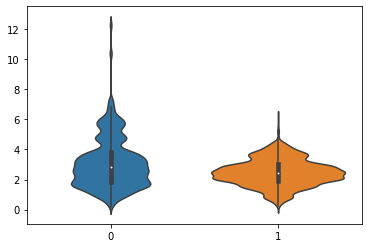

In [138]:
sns.violinplot(data=[cap_3P_errors, cap_HM_errors],orient='v')

Mann Whitney U test for independent measures: skip this and go to Wilcoxon test since our samples are now paired

In [139]:
u, p = stats.mannwhitneyu(cap_HM_errors,cap_3P_errors,alternative='less')

In [140]:
p

1.0680026028266911e-282

In [141]:
w, p = stats.wilcoxon(x=cap_HM_errors,y=cap_3P_errors,alternative='less')

In [142]:
p

0.0

Static Experiment CAP Algorithm: 3P and HM Tip Error


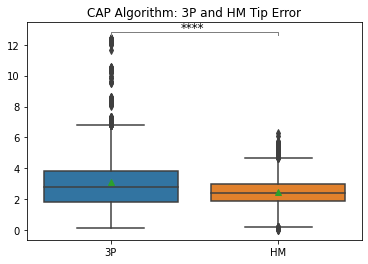

In [143]:
ax = sns.boxplot(data=[cap_3P_errors,cap_HM_errors],orient='v',showmeans=True)
print('Static Experiment CAP Algorithm: 3P and HM Tip Error')
max_y = max(np.max(cap_3P_errors),np.max(cap_HM_errors))
if p < p_val_adj: # draw a significance line
    star_str = disp_utils.get_p_stars(p)
    starline_y = max_y
    ax.plot([0, 0, 1, 1], [starline_y+0.2, starline_y+0.4, starline_y+0.4, starline_y+0.2], linewidth=1, color='grey')
    ax.text(0.49, starline_y+0.5, star_str, ha='center', fontsize=12)
ax.set_title('CAP Algorithm: 3P and HM Tip Error')
ax.set_xticklabels(['3P','HM'])
plt.savefig('../reports/figures/static/CAP-3PvsHM-boxplot.pdf',dpi=600)
plt.show()

#### CAP: compare the means 
Compare mean tip errors from hadamard and three-projection sequences for CAP algorithm: get the means from each 3d grid location, from all catheters, using the means of the Biases_Crop columns (to ensure the same number of samples are used)

In [144]:
cap_3P_mean_errors = []
cap_HM_mean_errors = []
for y in y_locs:
    for g in grid_locs:
        proj_biases = cap_df[(cap_df['Sequence']=='SRI_Original') & (cap_df['Y_Loc']==y) & (cap_df['Grid_Loc']==g)]['Mean_Bias'].ravel()
        hm_biases = cap_df[(cap_df['Sequence']=='FH512_noDither_gradSpoiled') & (cap_df['Y_Loc']==y) & (cap_df['Grid_Loc']==g)]['Mean_Bias'].ravel()
        proj_biases = proj_biases[~np.isnan(proj_biases)]
        hm_biases = hm_biases[~np.isnan(hm_biases)]
        cap_3P_mean_errors.append(np.mean(proj_biases))
        cap_HM_mean_errors.append(np.mean(hm_biases))

In [145]:
np.mean(cap_3P_mean_errors)

3.0547507652106027

In [146]:
np.std(cap_3P_mean_errors)

1.0067931077309

In [147]:
np.mean(cap_HM_mean_errors)

2.4107480612191976

In [148]:
np.std(cap_HM_mean_errors)

0.5491559558392825

In [149]:
w, p = stats.wilcoxon(x=cap_HM_mean_errors,y=cap_3P_mean_errors,alternative='less')

In [150]:
p

0.00016547173050728041

Static Experiment CAP Algorithm: 3P and HM Mean Tip Error


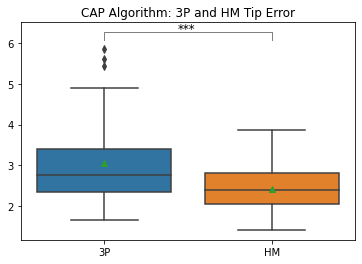

In [151]:
ax = sns.boxplot(data=[cap_3P_mean_errors,cap_HM_mean_errors],orient='v',showmeans=True)
print('Static Experiment CAP Algorithm: 3P and HM Mean Tip Error')
max_y = max(np.max(cap_3P_mean_errors),np.max(cap_HM_mean_errors))
if p < p_val_adj: # draw a significance line
    star_str = disp_utils.get_p_stars(p)
    starline_y = max_y
    ax.plot([0, 0, 1, 1], [starline_y+0.2, starline_y+0.4, starline_y+0.4, starline_y+0.2], linewidth=1, color='grey')
    ax.text(0.49, starline_y+0.4, star_str, ha='center', fontsize=12)
ax.set_title('CAP Algorithm: 3P and HM Tip Error')
ax.set_xticklabels(['3P','HM'])
plt.savefig('../reports/figures/static/CAP-3PvsHM-mean_boxplot.pdf',dpi=600)
plt.show()

# HDF5 Exports
Error data has been saved to hdf5 (Hierarchical Data Format) files, one file for each sequence and algorithm combination. These can be read using your own code for further analysis, as shown in the code snippet below.

We check that we can open and read the most recent hdf5 file. The catheter error arrays are stored as datasets within this file.

Output the first dataset as an array from this file. This is a 2d array containing the tip errors for this catheter.

For each grid position:
the ground truth X coordinate, Z coordinate, bias (tip error) in mm, tip variance in mm (in that order)

So, there are 16 elements arranged like:

`[ [GT_x_pos0, GT_z_pos0, bias_pos0, variance_pos0], [GT_x_pos1, GT_z_pos1, bias_pos1, variance_pos1], ... [GT_x_pos15, GT_z_pos15, bias_pos15, variance_pos2] ]`

In [152]:
with h5py.File(h5out, 'r', libver='latest') as f:
    first_dataset = list(f.keys())[0]

    print("Looking at catheter tip errors for " + first_dataset \
          + "\n from the file: " + h5out)
    
    # Can also use h5py dataset object: ds_obj = f[a_group_key]
    # The 2d array contains the tip error for this catheter
    ds_arr = f[first_dataset][()]  # returns as a numpy array
    print(ds_arr)

Looking at catheter tip errors for static_err_FH512_noDither_gradSpoiled_jpng_trackTest-7Jan2022-C306-Y2
 from the file: ../reports/export/static/Y2_FH512_noDither_gradSpoiled_jpng.h5
[[-3.80553565e+00 -1.87287835e+01  3.01430331e+00  1.90963368e-02
   1.78000000e+02]
 [ 2.96936945e+01 -1.86500552e+01  2.52192775e+00  6.63732145e-03
   1.75000000e+02]
 [ 6.26533407e+01 -1.88988546e+01  1.75275943e+00  1.70920807e-02
   1.75000000e+02]
 [ 9.62574016e+01 -1.85214438e+01  1.59943733e+00  3.41239821e-03
   1.75000000e+02]
 [ 9.64131762e+01  1.65016458e+01  2.20761256e+00  6.07945832e-03
   1.80000000e+02]
 [ 6.30397218e+01  1.63046923e+01  1.77709769e+00  1.32166745e-02
   1.77000000e+02]
 [ 2.93706112e+01  1.61286079e+01  2.81292745e+00  4.22867173e-02
   1.83000000e+02]
 [-3.41449462e+00  1.57894111e+01  3.22256336e+00  8.85141825e-03
   1.75000000e+02]
 [-4.17528641e+00  4.91897834e+01  1.17789751e+00  6.27023489e-03
   1.75000000e+02]
 [ 2.84294862e+01  4.92649623e+01  1.23534200e+00  